# 2025-06-14 - Alpha diversity

## Summary

This notebook is part of the 1st July sprint to get a draft. Here, I'll consider the alpha-diversity of our Motus-g1 data, including:
- Diversity according to different metrics. 
- Rarefication of the samples to account for sampling depth.
- Comparison of diversity between sites. 
- Correlation of the diversity with environmental traits (e.g. habitat type)


## Load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

habitat_palette = {
    "Crop": "#0CAB7B", 
    "Edge": "#3A8DFA", 
    "Oak": "#FB2231",
    "Wasteland": "#FFC51F"
}

from skbio.diversity.alpha import shannon, chao1, faith_pd
from skbio import TreeNode
import scikit_posthocs as sp
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from rdflib import Graph
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
data = Graph()
data.parse(open("data/miripvir.2025-07-09.ttl"))

<Graph identifier=Nedf064c000ac47209728eed356801c71 (<class 'rdflib.graph.Graph'>)>

In [3]:
res = data.query(
"""
PREFIX mvrtaxon: <http://localhost:8000/taxon/>
PREFIX mvrlib: <http://localhost:8000/library/>
PREFIX mvront: <http://localhost:8000/ont/>
PREFIX mvrcol: <http://localhost:8000/collection/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#> 
PREFIX emi: <https://purl.org/emi#>
PREFIX uniprotrdfs: <http://purl.uniprot.org/core/>

SELECT  ?taxid ?scientific_name ?gtdb_genome_representative ?site ?habitat (COUNT(?lib) AS ?number_hits)
WHERE {
    ?lib mvront:Reported ?hit .
    ?hit mvront:BelongsTo mvrcol:0000 .
    ?hit uniprotrdfs:Taxon ?taxon .
    ?taxon mvront:is_pab "true" .
    ?taxon dwc:taxonID ?taxid .
    ?taxon dwc:scientificName ?scientific_name .
    ?taxon mvront:GTDBGenomeReference ?gtdb_genome_representative .
    ?lib mvront:Sampled_from ?s .
    ?s rdfs:label ?site .
    ?s wlo:habitat ?habitat .
} GROUP BY ?scientific_name ?site

"""
)
detections = pd.DataFrame(res, columns=list(map(str, res.vars)))
detections['number_hits'] = detections['number_hits'].astype(int) 
detections['scientific_name'] = detections['scientific_name'].apply(lambda x: str(x))
detections['gtdb_genome_representative'] = detections['gtdb_genome_representative'].apply(lambda x: str(x))
detections['site'] = detections['site'].apply(lambda x: str(x))
detections['habitat'] = detections['habitat'].apply(lambda x: str(x))
detections

,taxid,scientific_name,gtdb_genome_representative,site,habitat,number_hits
0,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M1,Crop,3
1,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,Q1,Oak,2
2,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M2,Crop,2
3,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M3,Crop,1
4,29448,Bradyrhizobium elkanii,RS GCF 023278185.1,M4,Crop,1
...,...,...,...,...,...,...
294,1933817,Kribbella sp. ALI-6-A,RS GCF 001984195.1,Z2,Crop,1
295,1566262,Rhizobium sp. NFR07,RS GCF 900111905.1,Z2,Crop,1
296,1770058,Devosia elaeis,RS GCF 001650025.1,Z2,Crop,1
297,1735683,Sphingomonas sp. Leaf17,RS GCF 001421505.1,C1,Crop,1


In [4]:
detections.query('site == "H1"')

,taxid,scientific_name,gtdb_genome_representative,site,habitat,number_hits
206,317,Pseudomonas syringae,RS GCF 023278085.1,H1,Crop,1


In [5]:
type(detections.loc[4]['scientific_name'])

str

In [6]:
# motus_df = pd.read_csv("../results/2025-06-13.sprint/base.motus-hits.csv", sep=';')
# motus_df

In [7]:
tree = TreeNode.read("data/bac120.tree")

## Direct calculations

In this section, we will avoid rarefication. 

In [8]:
alpha_diversity = detections.value_counts(
    ['site', 'habitat', 'taxid', 'gtdb_genome_representative']
    ).reset_index().groupby(
        ['site', 'habitat']
    )['count'].apply(list).reset_index().rename(columns={'count': 'hits'})
alpha_diversity

,site,habitat,hits
0,C1,Crop,"[1, 1, 1, 1, 1, 1]"
1,C2,Crop,"[1, 1, 1, 1, 1, 1, 1, 1]"
2,E1,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
3,E2,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
4,E3,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
5,E4,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
6,H1,Crop,[1]
7,H2,Crop,[1]
8,H3,Crop,"[1, 1, 1, 1]"
9,L1,Edge,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [9]:
alpha_diversity['species_richness'] = alpha_diversity['hits'].apply(lambda x: len(x))
alpha_diversity['shannon'] = alpha_diversity['hits'].apply(shannon)
alpha_diversity['chao1'] = alpha_diversity['hits'].apply(chao1)
alpha_diversity

,site,habitat,hits,species_richness,shannon,chao1
0,C1,Crop,"[1, 1, 1, 1, 1, 1]",6,1.791759,21.0
1,C2,Crop,"[1, 1, 1, 1, 1, 1, 1, 1]",8,2.079442,36.0
2,E1,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",12,2.484907,78.0
3,E2,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",13,2.564949,91.0
4,E3,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",15,2.708050,120.0
5,E4,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",46,3.828641,1081.0
6,H1,Crop,[1],1,0.000000,1.0
7,H2,Crop,[1],1,0.000000,1.0
8,H3,Crop,"[1, 1, 1, 1]",4,1.386294,10.0
9,L1,Edge,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",20,2.995732,210.0


In [10]:
faith_alpha_diversity = pd.merge(
    detections.dropna(subset=['gtdb_genome_representative']).value_counts(
    ['site', 'habitat', 'gtdb_genome_representative']
    ).reset_index().groupby(
        ['site', 'habitat']
    )['count'].apply(list).reset_index().rename(columns={'count': 'hits'}),
    detections.dropna(subset=['gtdb_genome_representative']).value_counts(
        ['site', 'habitat', 'gtdb_genome_representative']
    ).reset_index().groupby(
        ['site', 'habitat']
    )['gtdb_genome_representative'].apply(list).reset_index().rename(columns={'gtdb_genome_representative': 'gtdb-rep'}),
    on=['site', 'habitat'], how='inner'
)

faith_alpha_diversity


,site,habitat,hits,gtdb-rep
0,C1,Crop,"[1, 1, 1, 1, 1, 1]","[RS GCF 000023205.1, RS GCF 001411475.1, RS GC..."
1,C2,Crop,"[1, 1, 1, 1, 1, 1, 1, 1]","[RS GCF 025451635.1, RS GCF 011759585.1, RS GC..."
2,E1,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[RS GCF 001421435.1, RS GCF 000759445.1, RS GC..."
3,E2,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[RS GCF 900067135.1, RS GCF 019047785.1, RS GC..."
4,E3,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[RS GCF 900113485.1, RS GCF 900111275.1, RS GC..."
5,E4,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[GB GCA 013337045.2, GB GCA 003240625.1, RS GC..."
6,H1,Crop,[1],[RS GCF 023278085.1]
7,H2,Crop,[1],[RS GCF 002259415.1]
8,H3,Crop,"[1, 1, 1, 1]","[RS GCF 001421705.1, RS GCF 900113115.1, RS GC..."
9,L1,Edge,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[RS GCF 025451635.1, RS GCF 017876815.1, RS GC..."


In [11]:
faith_alpha_diversity['faithpd'] = faith_alpha_diversity.apply(lambda x: faith_pd(x['hits'], x['gtdb-rep'], tree), axis=1)

In [12]:
alpha_diversity =pd.merge(alpha_diversity, faith_alpha_diversity[['site', 'faithpd']], on='site')

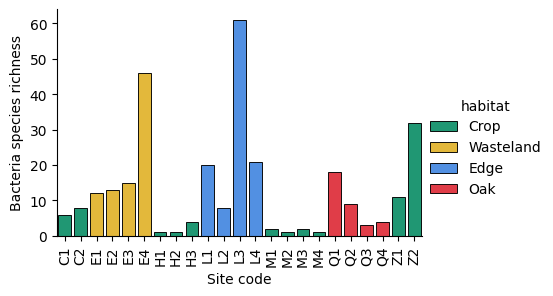

In [13]:
g = sns.catplot(alpha_diversity, x='site', y='species_richness', height=3.0, aspect=1.5, kind='bar', hue='habitat', palette=habitat_palette, edgecolor='black', linewidth=0.65)
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Bacteria species richness")
g.set_xlabels("Site code")
g.set_xticklabels(rotation=90)

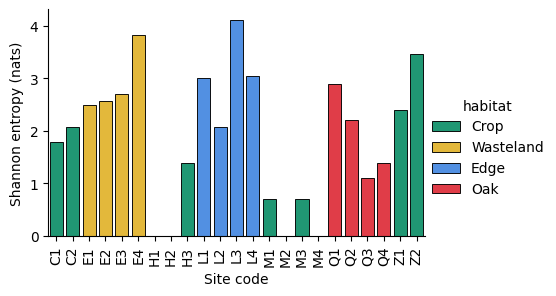

In [14]:
g = sns.catplot(alpha_diversity, x='site', y='shannon', height=3.0, aspect=1.5, kind='bar', hue='habitat', palette=habitat_palette, edgecolor='black', linewidth=0.65)
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Shannon entropy (nats)")
g.set_xlabels("Site code")
g.set_xticklabels(rotation=90)
# g.savefig("../figures/draft0-figures/Fig2B.00.svg")

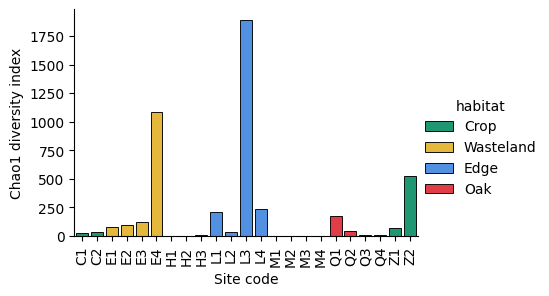

In [15]:
g = sns.catplot(alpha_diversity, x='site', y='chao1', height=3.0, aspect=1.5, kind='bar', hue='habitat', palette=habitat_palette, edgecolor='black', linewidth=0.65)
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Chao1 diversity index")
g.set_xlabels("Site code")
g.set_xticklabels(rotation=90)

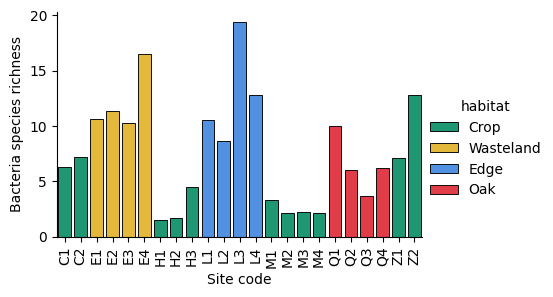

In [16]:
g = sns.catplot(alpha_diversity, x='site', y='faithpd', height=3.0, aspect=1.5, kind='bar', hue='habitat', palette=habitat_palette, edgecolor='black', linewidth=0.65)
g.set_ylabels("Bacteria species richness")
g.set_xlabels("Site code")
g.set_xticklabels(rotation=90)

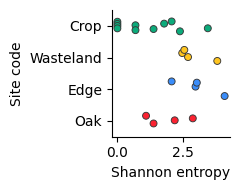

In [17]:
g = sns.catplot(
    alpha_diversity, y='habitat', x='shannon', height=2.0, aspect=1.25, 
    hue='habitat', palette=habitat_palette, linewidth=0.65, jitter=0.25)
g.set_xlabels("Shannon entropy")
g.set_ylabels("Site code")
g.savefig("figures/figure3.shannon.svg")
# g.set_xticklabels(rotation=90)

### Joint representations

/home/bcz/miniconda3/envs/miripvir25/lib/python3.9/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


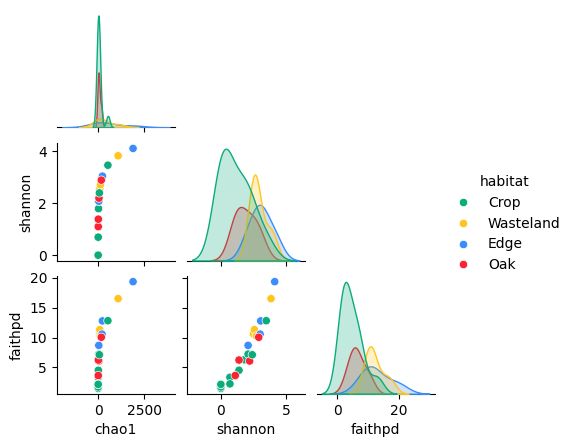

In [18]:
sns.pairplot(
    data=alpha_diversity[['habitat', 'chao1', 'shannon', 'faithpd']], 
    hue='habitat', palette=habitat_palette, size=1.5, corner=True
)

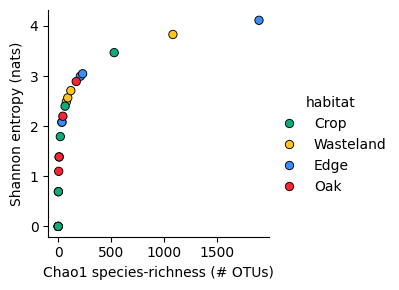

In [19]:
g = sns.relplot(data=alpha_diversity, x='chao1', y='shannon', hue='habitat', height=3.0, aspect=1.0, linewidth=0.65, edgecolor='black', palette=habitat_palette)
g.set_xlabels("Chao1 species-richness (# OTUs)")
g.set_ylabels("Shannon entropy (nats)")

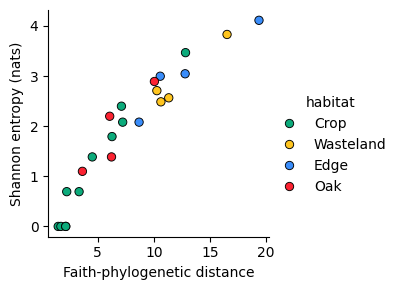

In [20]:
g = sns.relplot(data=alpha_diversity, x='faithpd', y='shannon', hue='habitat', height=3.0, aspect=1.0, linewidth=0.65, edgecolor='black', palette=habitat_palette)
g.set_xlabels("Faith-phylogenetic distance")
g.set_ylabels("Shannon entropy (nats)")

In [21]:
stats.linregress(alpha_diversity['shannon'], alpha_diversity['chao1'])

LinregressResult(slope=227.55291491570972, intercept=-232.51738155814326, rvalue=0.6521346997654183, pvalue=0.000746213907398884, stderr=57.72497155930966, intercept_stderr=131.13801412087795)

In [22]:
stats.linregress(alpha_diversity['shannon'], alpha_diversity['faithpd'])

LinregressResult(slope=3.70764810848053, intercept=0.6329676820443293, rvalue=0.9540729779483369, pvalue=1.823189608339873e-12, stderr=0.2540456707848333, intercept_stderr=0.5771340177881208)

### Statistics

#### Q1: Is any habitat more diverse than others?

In [23]:
q1_stats = []
for metric in ['chao1', 'shannon', 'faithpd']:
    kw_h, pval = stats.kruskal(
        alpha_diversity.query('habitat == "Crop"')[metric].values,
        alpha_diversity.query('habitat == "Edge"')[metric].values,
        alpha_diversity.query('habitat == "Wasteland"')[metric].values,
        alpha_diversity.query('habitat == "Oak"')[metric].values
    )
    significative = pval < 0.05
    q1_stats.append(
        {'metric': metric, 'H': kw_h, 'p-val': pval, 'sign': significative}
    )
q1_stats = pd.DataFrame.from_records(q1_stats)
q1_stats

,metric,H,p-val,sign
0,chao1,10.425410,0.015276,True
1,shannon,10.425410,0.015276,True
2,faithpd,12.089965,0.007081,True


#### Q2: Which ones? 

In [24]:

q2_stats = []
habitats = ['Crop', 'Edge', 'Wasteland', 'Oak']
for metric in ['chao1', 'shannon', 'faithpd']:

    q2_test = sp.posthoc_dunn(
        [
            alpha_diversity.query('habitat == "Crop"')[metric].values,
            alpha_diversity.query('habitat == "Edge"')[metric].values,
            alpha_diversity.query('habitat == "Wasteland"')[metric].values,
            alpha_diversity.query('habitat == "Oak"')[metric].values
        ],
        p_adjust='holm'
    )

    for i, row in q2_test.iterrows():
        for j, col in enumerate(list(row)):
            q2_stats.append(
                {'metric': metric, 'habitat1': habitats[i - 1], 'habitat2': habitats[j], 'pval': col, 'sign': col < 0.05}
            )
q2_stats = pd.DataFrame.from_records(q2_stats)
q2_stats

,metric,habitat1,habitat2,pval,sign
0,chao1,Crop,Crop,1.000000,False
1,chao1,Crop,Edge,0.044912,True
2,chao1,Crop,Wasteland,0.070879,False
3,chao1,Crop,Oak,0.669678,False
4,chao1,Edge,Crop,0.044912,True
5,chao1,Edge,Edge,1.000000,False
6,chao1,Edge,Wasteland,0.854768,False
7,chao1,Edge,Oak,0.631783,False
8,chao1,Wasteland,Crop,0.070879,False
9,chao1,Wasteland,Edge,0.854768,False


In [25]:
q2_stats.query('sign == True')

,metric,habitat1,habitat2,pval,sign
1,chao1,Crop,Edge,0.044912,True
4,chao1,Edge,Crop,0.044912,True
17,shannon,Crop,Edge,0.044912,True
20,shannon,Edge,Crop,0.044912,True
33,faithpd,Crop,Edge,0.034871,True
34,faithpd,Crop,Wasteland,0.034551,True
36,faithpd,Edge,Crop,0.034871,True
40,faithpd,Wasteland,Crop,0.034551,True


#### Q3: Could alpha-diversity at micro-organism level be correlated with diversity at host level?

In [26]:
res = data.query(
"""
PREFIX mvrtaxon: <http://localhost:8000/taxon/>
PREFIX mvrlib: <http://localhost:8000/library/>
PREFIX mvront: <http://localhost:8000/ont/>
PREFIX mvrcol: <http://localhost:8000/collection/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#> 
PREFIX emi: <https://purl.org/emi#>
PREFIX uniprotrdfs: <http://purl.uniprot.org/core/>

SELECT  ?lib ?scientific_name ?n_extracts ?site ?habitat
WHERE {
    ?l mvront:Obtained_from ?host .
    ?l rdfs:label ?lib .
    ?host uniprotrdfs:Taxon ?taxon .
    ?taxon dwc:scientificName ?scientific_name .
    ?l mvront:Sampled_from ?s .
    ?s rdfs:label ?site .
    ?s wlo:habitat ?habitat .
    ?l mvront:nextracts ?n_extracts
}

"""
)
hosts = pd.DataFrame(res, columns=list(map(str, res.vars)))
hosts['n_extracts'] = hosts['n_extracts'].apply(lambda x: int(x))
hosts['site'] = hosts['site'].apply(lambda x: str(x))
hosts['scientific_name'] = hosts['scientific_name'].apply(lambda x: str(x))
hosts['habitat'] = hosts['habitat'].apply(lambda x: str(x))


In [27]:
host_alpha_diversity = hosts.groupby(
    ['site', 'habitat'], as_index=False
)['n_extracts'].apply(list)

In [28]:
host_alpha_diversity['shannon'] = host_alpha_diversity['n_extracts'].apply(shannon)
host_alpha_diversity['chao1'] = host_alpha_diversity['n_extracts'].apply(chao1)

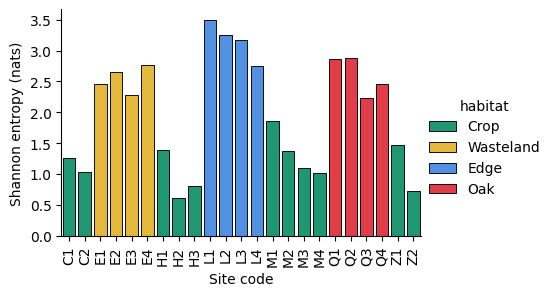

In [29]:
g = sns.catplot(host_alpha_diversity, x='site', y='shannon', height=3.0, aspect=1.5, kind='bar', hue='habitat', palette=habitat_palette, edgecolor='black', linewidth=0.65)
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Shannon entropy (nats)")
g.set_xlabels("Site code")
g.set_xticklabels(rotation=90)

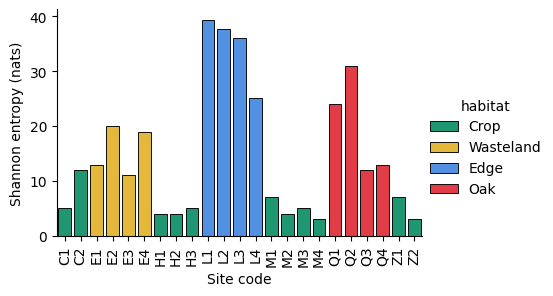

In [30]:
g = sns.catplot(host_alpha_diversity, x='site', y='chao1', height=3.0, aspect=1.5, kind='bar', hue='habitat', palette=habitat_palette, edgecolor='black', linewidth=0.65)
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Shannon entropy (nats)")
g.set_xlabels("Site code")
g.set_xticklabels(rotation=90)

In [31]:
alpha_diversity = pd.merge(alpha_diversity, host_alpha_diversity, on='site', suffixes=['_bact', '_host'])

In [32]:
alpha_diversity

,site,habitat_bact,hits,species_richness,shannon_bact,chao1_bact,faithpd,habitat_host,n_extracts,shannon_host,chao1_host
0,C1,Crop,"[1, 1, 1, 1, 1, 1]",6,1.791759,21.0,6.280788,Crop,"[3, 17, 8, 1, 4]",1.264957,5.000000
1,C2,Crop,"[1, 1, 1, 1, 1, 1, 1, 1]",8,2.079442,36.0,7.230443,Crop,"[1, 1, 1, 17, 3, 1]",1.033868,12.000000
2,E1,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",12,2.484907,78.0,10.633520,Wasteland,"[19, 8, 8, 11, 6, 10, 8, 8, 5, 6, 15, 3, 6]",2.460975,13.000000
3,E2,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",13,2.564949,91.0,11.332095,Wasteland,"[11, 6, 11, 11, 13, 1, 3, 7, 1, 1, 8, 6, 8, 4,...",2.648773,20.000000
4,E3,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",15,2.708050,120.0,10.273612,Wasteland,"[9, 1, 3, 3, 7, 6, 3, 8, 4, 5, 5]",2.279548,11.000000
5,E4,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",46,3.828641,1081.0,16.521537,Wasteland,"[23, 24, 15, 8, 7, 14, 16, 11, 10, 5, 8, 8, 27...",2.758323,19.000000
6,H1,Crop,[1],1,0.000000,1.0,1.489563,Crop,"[8, 8, 8, 8]",1.386294,4.000000
7,H2,Crop,[1],1,0.000000,1.0,1.728278,Crop,"[40, 1, 4, 3]",0.612947,4.000000
8,H3,Crop,"[1, 1, 1, 1]",4,1.386294,10.0,4.525191,Crop,"[9, 1, 24, 1]",0.811111,5.000000
9,L1,Edge,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",20,2.995732,210.0,10.574458,Edge,"[6, 8, 7, 3, 4, 5, 2, 1, 3, 2, 4, 3, 5, 2, 6, ...",3.496305,39.352941


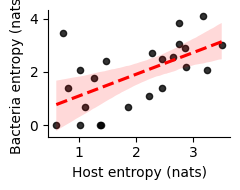

In [33]:
g = sns.lmplot(
    data=alpha_diversity, y='shannon_bact', x='shannon_host', 
    palette=habitat_palette, height=2.0, aspect=1.25, 
    scatter_kws={'edgecolor': 'black', 'color': 'black', 's':20},
    line_kws={'color':'red', 'linestyle': '--'}
    #edgecolor='black'
)
g.set_ylabels("Bacteria entropy (nats)")
g.set_xlabels("Host entropy (nats)")
g.tight_layout()
g.savefig("figures/fig03.shannon-shannon.svg")

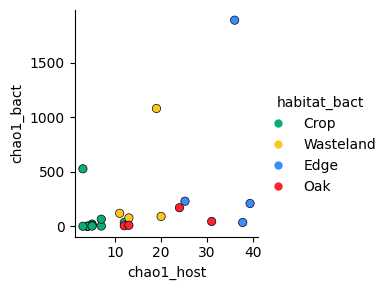

In [34]:
sns.relplot(
    data=alpha_diversity, y='chao1_bact', x='chao1_host', 
    hue='habitat_bact', palette=habitat_palette, height=3.0,
    edgecolor='black'
)

In [35]:
formula = 'chao1_bact ~ chao1_host'
model = smf.glm(formula=formula, data=alpha_diversity, family=sm.families.Gaussian()).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             chao1_bact   No. Observations:                   23
Model:                            GLM   Df Residuals:                       21
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                      1.6778e+05
Method:                          IRLS   Log-Likelihood:                -169.94
Date:                mié, 09 jul 2025   Deviance:                   3.5234e+06
Time:                        12:29:00   Pearson chi2:                 3.52e+06
No. Iterations:                     3   Pseudo R-squ. (CS):             0.1753
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -23.0885    137.628     -0.168      0.8

In [36]:
formula = 'shannon_bact ~ shannon_host'
model = smf.glm(formula=formula, data=alpha_diversity, family=sm.families.Gaussian()).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           shannon_bact   No. Observations:                   23
Model:                            GLM   Df Residuals:                       21
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                          1.0883
Method:                          IRLS   Log-Likelihood:                -32.562
Date:                mié, 09 jul 2025   Deviance:                       22.853
Time:                        12:29:01   Pearson chi2:                     22.9
No. Iterations:                     3   Pseudo R-squ. (CS):             0.3850
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.2753      0.537      0.513   

In [37]:
alpha_diversity

,site,habitat_bact,hits,species_richness,shannon_bact,chao1_bact,faithpd,habitat_host,n_extracts,shannon_host,chao1_host
0,C1,Crop,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",12,2.484907,78.0,12.193962,Crop,"[3, 17, 8, 1, 4]",1.264957,5.000000
1,C2,Crop,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",19,2.944439,190.0,14.567238,Crop,"[1, 1, 1, 17, 3, 1]",1.033868,12.000000
2,E1,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",30,3.401197,465.0,18.329618,Wasteland,"[19, 8, 8, 11, 6, 10, 8, 8, 5, 6, 15, 3, 6]",2.460975,13.000000
3,E2,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",38,3.637586,741.0,21.337908,Wasteland,"[11, 6, 11, 11, 13, 1, 3, 7, 1, 1, 8, 6, 8, 4,...",2.648773,20.000000
4,E3,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",35,3.555348,630.0,20.040000,Wasteland,"[9, 1, 3, 3, 7, 6, 3, 8, 4, 5, 5]",2.279548,11.000000
5,E4,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",96,4.564348,4656.0,33.405923,Wasteland,"[23, 24, 15, 8, 7, 14, 16, 11, 10, 5, 8, 8, 27...",2.758323,19.000000
6,H1,Crop,"[1, 1, 1, 1]",4,1.386294,10.0,5.171802,Crop,"[8, 8, 8, 8]",1.386294,4.000000
7,H2,Crop,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",11,2.397895,66.0,10.774359,Crop,"[40, 1, 4, 3]",0.612947,4.000000
8,H3,Crop,"[1, 1, 1, 1, 1, 1, 1]",7,1.945910,28.0,6.290971,Crop,"[9, 1, 24, 1]",0.811111,5.000000
9,L1,Edge,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",62,4.127134,1953.0,26.342917,Edge,"[6, 8, 7, 3, 4, 5, 2, 1, 3, 2, 4, 3, 5, 2, 6, ...",3.496305,39.352941


In [38]:
alpha_diversity[['site', 'species_richness', 'shannon_bact', 'chao1_bact', 'faithpd', 'shannon_host', 'chao1_host']]# .to_csv("../results/2025-06-13.sprint/analysis.alpha-diversity.csv", sep=';', index=None)

,site,species_richness,shannon_bact,chao1_bact,faithpd,shannon_host,chao1_host
0,C1,12,2.484907,78.0,12.193962,1.264957,5.000000
1,C2,19,2.944439,190.0,14.567238,1.033868,12.000000
2,E1,30,3.401197,465.0,18.329618,2.460975,13.000000
3,E2,38,3.637586,741.0,21.337908,2.648773,20.000000
4,E3,35,3.555348,630.0,20.040000,2.279548,11.000000
5,E4,96,4.564348,4656.0,33.405923,2.758323,19.000000
6,H1,4,1.386294,10.0,5.171802,1.386294,4.000000
7,H2,11,2.397895,66.0,10.774359,0.612947,4.000000
8,H3,7,1.945910,28.0,6.290971,0.811111,5.000000
9,L1,62,4.127134,1953.0,26.342917,3.496305,39.352941


## Host alpha-diversity

In [37]:
host_abundances_byhabitat = pd.read_csv("data/mcleish24-TableS7.csv", sep='\t').query('RelativeAbundance > 0')
host_abundances_byhabitat

,Habitat,Species_name,RelativeAbundance
0,Crop,Cucumis melo,276
1,Crop,Hordeum vulgare,168
2,Crop,Brassica oleracea,109
3,Crop,Zea mays,67
4,Crop,Datura stramonium,57
...,...,...,...
929,Wasteland,Stipa tenacissima,1
930,Wasteland,Trifolium campestre,1
931,Wasteland,Trifolium hirtum,1
932,Wasteland,Umbelifera sp,1


In [38]:
host_abundances_byhabitat.pivot(index='Species_name', columns='Habitat', values='RelativeAbundance').fillna(0)

Habitat,Crop,Edge,Oak,Wasteland
Species_name,,,,
Acinos rotundifolium,0.0,0.0,0.0,1.0
Adonis flammea,2.0,0.0,0.0,0.0
Agrimonia eupatoria,0.0,1.0,2.0,0.0
Ajuga chamaepitys,0.0,0.0,3.0,0.0
Allium sativum,5.0,1.0,0.0,0.0
...,...,...,...,...
Veronica persica,1.0,0.0,0.0,0.0
Veronica sp,0.0,0.0,0.0,1.0
Vicia sp,1.0,3.0,0.0,16.0


In [39]:
host_abundances_byhabitat_groupedbyhabitat = host_abundances_byhabitat.groupby(['Habitat'], as_index=False)['RelativeAbundance'].apply(list)
host_abundances_byhabitat_groupedbyhabitat['shannon'] = host_abundances_byhabitat_groupedbyhabitat['RelativeAbundance'].apply(shannon)
host_abundances_byhabitat_groupedbyhabitat

,Habitat,RelativeAbundance,shannon
0,Crop,"[276, 168, 109, 67, 57, 44, 41, 31, 23, 23, 23...",3.052679
1,Edge,"[160, 57, 51, 48, 46, 40, 39, 36, 36, 32, 26, ...",3.790402
2,Oak,"[334, 166, 115, 100, 94, 84, 77, 59, 56, 51, 5...",3.744530
3,Wasteland,"[150, 128, 94, 85, 80, 79, 73, 63, 61, 58, 55,...",4.101519


### Real species richness

In the following block, I compute the species richness. I will use a file provided by Marco, which contains the number of species per habitat. This is not exactly the data that I would like to use here, as it does not offer a measure of the abundance / evenness of the organisms here involved, but the real file's location is unknown right now.

The hypothesis, as above, is that the diversity of the hosts is correlated with the diversity of the bacteria, which would also support the idea of specific interactions between bacteria and hosts.

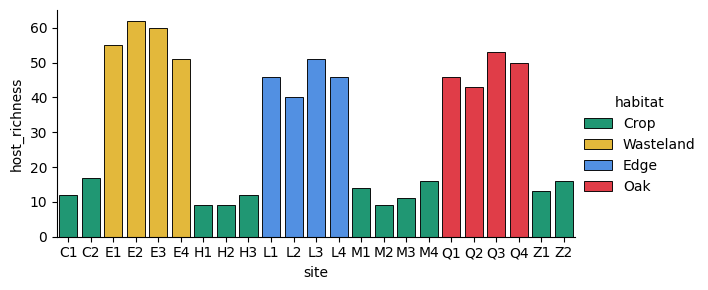

In [40]:
real_species_richness = pd.read_csv("data/host.species-richness.csv", sep="\t").sort_values(by='site')
sns.catplot(
    data=real_species_richness, 
    x='site', y='host_richness', 
    height=3.0, aspect=2.0, kind='bar', hue='habitat', palette=habitat_palette, edgecolor='black', linewidth=0.65
)

In [41]:
alpha_diversity = pd.merge(alpha_diversity, real_species_richness, on='site', suffixes=['_bact', '_host'])

In [44]:
alpha_diversity

,site,habitat_bact,hits,species_richness,shannon_bact,chao1_bact,faithpd,habitat_host,n_extracts,shannon_host,chao1_host,habitat,host_richness
0,C1,Crop,"[1, 1, 1, 1, 1, 1]",6,1.791759,21.0,6.280788,Crop,"[3, 17, 8, 1, 4]",1.264957,5.000000,Crop,12
1,C2,Crop,"[1, 1, 1, 1, 1, 1, 1, 1]",8,2.079442,36.0,7.230443,Crop,"[1, 1, 1, 17, 3, 1]",1.033868,12.000000,Crop,17
2,E1,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",12,2.484907,78.0,10.633520,Wasteland,"[19, 8, 8, 11, 6, 10, 8, 8, 5, 6, 15, 3, 6]",2.460975,13.000000,Wasteland,55
3,E2,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",13,2.564949,91.0,11.332095,Wasteland,"[11, 6, 11, 11, 13, 1, 3, 7, 1, 1, 8, 6, 8, 4,...",2.648773,20.000000,Wasteland,62
4,E3,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",15,2.708050,120.0,10.273612,Wasteland,"[9, 1, 3, 3, 7, 6, 3, 8, 4, 5, 5]",2.279548,11.000000,Wasteland,60
5,E4,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",46,3.828641,1081.0,16.521537,Wasteland,"[23, 24, 15, 8, 7, 14, 16, 11, 10, 5, 8, 8, 27...",2.758323,19.000000,Wasteland,51
6,H1,Crop,[1],1,0.000000,1.0,1.489563,Crop,"[8, 8, 8, 8]",1.386294,4.000000,Crop,9
7,H2,Crop,[1],1,0.000000,1.0,1.728278,Crop,"[40, 1, 4, 3]",0.612947,4.000000,Crop,9
8,H3,Crop,"[1, 1, 1, 1]",4,1.386294,10.0,4.525191,Crop,"[9, 1, 24, 1]",0.811111,5.000000,Crop,12
9,L1,Edge,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",20,2.995732,210.0,10.574458,Edge,"[6, 8, 7, 3, 4, 5, 2, 1, 3, 2, 4, 3, 5, 2, 6, ...",3.496305,39.352941,Edge,46


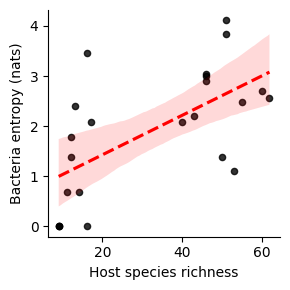

In [45]:
g = sns.lmplot(
    data=alpha_diversity, y='shannon_bact', x='host_richness', 
    palette=habitat_palette, height=3.0, aspect=1.0, 
    scatter_kws={'edgecolor': 'black', 'color': 'black', 's':20},
    line_kws={'color':'red', 'linestyle': '--'}
    #edgecolor='black'
)
g.set_ylabels("Bacteria entropy (nats)")
g.set_xlabels("Host species richness")
g.tight_layout()
# g.savefig("figures/fig03.shannon-shannon.svg")

In [47]:
stats.linregress(alpha_diversity['host_richness'], alpha_diversity['shannon_bact'])

LinregressResult(slope=0.03924544968804829, intercept=0.6441810172562508, rvalue=0.6202248629028603, pvalue=0.0015930469686070965, stderr=0.010831320362569358, intercept_stderr=0.4077490670405177)

In [49]:
alpha_diversity

,site,habitat_bact,hits,species_richness,shannon_bact,chao1_bact,faithpd,habitat_host,n_extracts,shannon_host,chao1_host,habitat,host_richness
0,C1,Crop,"[1, 1, 1, 1, 1, 1]",6,1.791759,21.0,6.280788,Crop,"[3, 17, 8, 1, 4]",1.264957,5.000000,Crop,12
1,C2,Crop,"[1, 1, 1, 1, 1, 1, 1, 1]",8,2.079442,36.0,7.230443,Crop,"[1, 1, 1, 17, 3, 1]",1.033868,12.000000,Crop,17
2,E1,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",12,2.484907,78.0,10.633520,Wasteland,"[19, 8, 8, 11, 6, 10, 8, 8, 5, 6, 15, 3, 6]",2.460975,13.000000,Wasteland,55
3,E2,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",13,2.564949,91.0,11.332095,Wasteland,"[11, 6, 11, 11, 13, 1, 3, 7, 1, 1, 8, 6, 8, 4,...",2.648773,20.000000,Wasteland,62
4,E3,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",15,2.708050,120.0,10.273612,Wasteland,"[9, 1, 3, 3, 7, 6, 3, 8, 4, 5, 5]",2.279548,11.000000,Wasteland,60
5,E4,Wasteland,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",46,3.828641,1081.0,16.521537,Wasteland,"[23, 24, 15, 8, 7, 14, 16, 11, 10, 5, 8, 8, 27...",2.758323,19.000000,Wasteland,51
6,H1,Crop,[1],1,0.000000,1.0,1.489563,Crop,"[8, 8, 8, 8]",1.386294,4.000000,Crop,9
7,H2,Crop,[1],1,0.000000,1.0,1.728278,Crop,"[40, 1, 4, 3]",0.612947,4.000000,Crop,9
8,H3,Crop,"[1, 1, 1, 1]",4,1.386294,10.0,4.525191,Crop,"[9, 1, 24, 1]",0.811111,5.000000,Crop,12
9,L1,Edge,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",20,2.995732,210.0,10.574458,Edge,"[6, 8, 7, 3, 4, 5, 2, 1, 3, 2, 4, 3, 5, 2, 6, ...",3.496305,39.352941,Edge,46


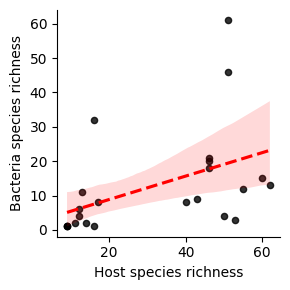

In [50]:
g = sns.lmplot(
    data=alpha_diversity, y='species_richness', x='host_richness', 
    palette=habitat_palette, height=3.0, aspect=1.0, 
    scatter_kws={'edgecolor': 'black', 'color': 'black', 's':20},
    line_kws={'color':'red', 'linestyle': '--'}
    #edgecolor='black'
)
g.set_ylabels("Bacteria species richness")
g.set_xlabels("Host species richness")
g.tight_layout()
# g.savefig("figures/fig03.shannon-shannon.svg")

In [51]:
stats.linregress(alpha_diversity['host_richness'], alpha_diversity['species_richness'])

LinregressResult(slope=0.340980239676178, intercept=2.0145061913022637, rvalue=0.44608783321724566, pvalue=0.03287863481396192, stderr=0.1492852756711661, intercept_stderr=5.619899498879279)

**Conclussion**: There is a significative correlation between host species richness and bacteria shannon entropy, but not with bacteria species richness. One one hand, it might be a bit hard to justify this, on the other hand, my plots are already using Shannon entropy.

## Host range

The host range is fundamental to understand the evolution of parasites (or whatever these bacteria are) into generalists or specialists. In this case, we would like to understand whether their host-range affects their prevalence across habitats. To understand so, we will analyze the correlation between the average abundance and the host-range. 

In [52]:
res = data.query(
"""
PREFIX mvrtaxon: <http://localhost:8000/taxon/>
PREFIX mvrlib: <http://localhost:8000/library/>
PREFIX mvront: <http://localhost:8000/ont/>
PREFIX mvrcol: <http://localhost:8000/collection/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#> 
PREFIX emi: <https://purl.org/emi#>
PREFIX uniprotrdfs: <http://purl.uniprot.org/core/>

SELECT  ?OTU ?taxon ?site
WHERE {
    ?lib mvront:Reported ?hit .
    ?lib mvront:Obtained_from ?host .
    ?lib mvront:Sampled_from ?s .
    ?hit mvront:BelongsTo mvrcol:0000 .
    ?hit uniprotrdfs:Taxon ?bacteria_taxon .
    ?bacteria_taxon mvront:is_pab "true" .
    ?host uniprotrdfs:Taxon ?host_taxon .
    ?bacteria_taxon dwc:scientificName ?OTU .
    ?host_taxon dwc:scientificName ?taxon .
    ?s rdfs:label ?site   
}

"""
)
hits = pd.DataFrame(res, columns=list(map(str, res.vars)))

hits['OTU'] = hits['OTU'].apply(str)
hits['taxon'] = hits['taxon'].apply(str)
hits['site'] = hits['site'].apply(str)
hits

,OTU,taxon,site
0,Bradyrhizobium elkanii,Cucumis melo,M1
1,Bradyrhizobium elkanii,Cyperus longus,M1
2,Bradyrhizobium elkanii,Teucrium pseudochamaepitys,Q1
3,Bradyrhizobium elkanii,Chenopodium album,M2
4,Bradyrhizobium elkanii,Cucumis melo,M2
...,...,...,...
418,Kribbella sp. ALI-6-A,Convolvulus arvensis,Z2
419,Rhizobium sp. NFR07,Convolvulus arvensis,Z2
420,Devosia elaeis,Convolvulus arvensis,Z2
421,Sphingomonas sp. Leaf17,Sisymbrium runcinatum,C1


In [53]:
total_detections_by_site = hits.value_counts(['site']).reset_index().rename(columns={'count': 'total'})
otu_detections_by_site = hits.value_counts(['OTU',  'site']).reset_index().rename(columns={'count': 'detections'})
detections_by_site = pd.merge(total_detections_by_site, otu_detections_by_site, on=['site'])
detections_by_site['AR'] = detections_by_site['detections'] / detections_by_site['total']
detections_by_site['AR2'] = detections_by_site['detections'] / len(hits)
detections_by_site = pd.merge(
    detections_by_site.groupby('OTU', as_index=False)['AR'].mean(), hits.value_counts(['OTU', 'taxon']).reset_index().value_counts(['OTU']).reset_index().rename(
        columns={'count': 'host_range'}
    ),
    on='OTU'
)
detections_by_site['lAR'] = detections_by_site['AR'].apply(np.log10)
# detections_by_site['lAR2'] = detections_by_site['AR2'].apply(np.log10)
detections_by_site['lhost_range'] = detections_by_site['host_range'].apply(np.log10)
detections_by_site

,OTU,AR,host_range,lAR,lhost_range
0,Achromobacter xylosoxidans,0.028629,1,-1.543193,0.000000
1,Acidovorax sp. Leaf160,0.012195,1,-1.913814,0.000000
2,Acidovorax sp. Leaf78,0.012195,1,-1.913814,0.000000
3,Acinetobacter baumannii,0.050000,1,-1.301030,0.000000
4,Acinetobacter pittii,0.039379,3,-1.404734,0.477121
...,...,...,...,...,...
120,Stutzerimonas stutzeri,0.043363,2,-1.362876,0.301030
121,Variovorax paradoxus,0.026931,2,-1.569749,0.301030
122,Xanthomonas campestris,0.060094,7,-1.221171,0.845098
123,Xaviernesmea rhizosphaerae,0.025000,1,-1.602060,0.000000


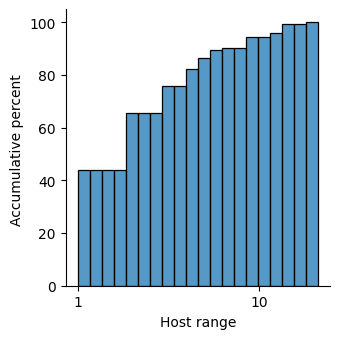

In [55]:
g = sns.displot(
    detections_by_site, x='lhost_range', height=3.5, bins=20 ,
    cumulative=True, stat='percent'
)
g.set_xlabels("Host range")
g.set_ylabels("Accumulative percent ")
g.ax.set_xticks([0.0, 1.0])
g.ax.set_xticklabels(['1', '10'])
# g.ax.set_xscale("log")
# g.ax.set_yscale("log")
g.savefig("figures/displot.host-range.svg")

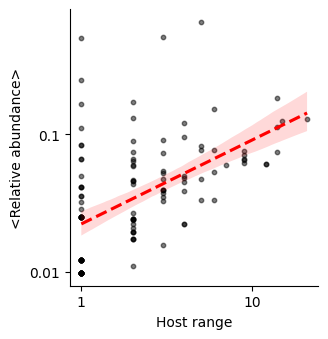

In [57]:
g = sns.lmplot(detections_by_site, x='lhost_range', y='lAR', height=3.5, 
               scatter_kws={'alpha':0.5, 's':10, 'color': 'black'}, line_kws={'color': 'red', 'linestyle':'--'}
               )
g.set_xlabels("Host range")
g.set_ylabels("<Relative abundance>")
g.ax.set_yticks([-1.0, -2.0])
g.ax.set_yticklabels(['0.1', '0.01'])
g.ax.set_xticks([0.0, 1.0])
g.ax.set_xticklabels(['1', '10'])
# g.ax.set_xscale("log")
# g.ax.set_yscale("log")
g.savefig("figures/lmplot.host-range.average-relative-abundance.svg")

In [58]:
stats.linregress(detections_by_site['lhost_range'], detections_by_site['lAR'])

LinregressResult(slope=0.6096110823688705, intercept=-1.650964953449537, rvalue=0.5276587388888626, pvalue=2.567573166592823e-10, stderr=0.08848879467351543, intercept_stderr=0.04176026892760341)

In [59]:
0.4059719279219045 ** 2

0.16481320626062804